# ResoKit's Tutorial

This tutorial is a guide to use ResoKit package.
ResoKit is toolkit package for the analysis and diagnostics of resonances in exoplanetary planetary systems.

In this tutorial we show, step by step, how to get started with the ResoKit package.

---

## Import ResoKit and the necessary packages

In [1]:
import resokit

## Loading the data

The first step is to load an exoplanetary system. The available datasets are [NASA](https://exoplanetarchive.ipac.caltech.edu/) or [EU](https://exoplanet.eu/home/).
Both datasets are provided with the package, and they can be updated if necessary.

To load a system, functions `load_system_from_nasa` and `load_system_from_eu` are provided in the `io` module.

For this turorial, we will work with the  `Kepler-47` exoplanetary system, from the Exoplanet.eu dataset.

In [2]:
kepler47 = resokit.io.load_system_from_eu("Kepler-47")

Loading star system Kepler-47 from eu.
 Loading exoplanet_eu.csv directly from datasets.zip...
 Storing the index columns into memory...
Star Kepler-47 not found in eu dataset.
 Similar names found in eu dataset:
 - ['Kepler-47 A', 'Kepler-471', 'Kepler-472', 'Kepler-473', 'Kepler-474', 'Kepler-475', 'Kepler-476', 'Kepler-478', 'Kepler-479']


If the system (or star in this case) name is entered incorrectly, ResoKit will attempt to detect the intended system and provide suggestions based on it.
As Exoplanet.eu is indexed through star name, we see here that the correct system (star) name is `Kepler-47 A`.

In [3]:
kepler47 = resokit.io.load_system_from_eu("Kepler-47 A")

Loading star system Kepler-47 A from eu.
 Loading exoplanet_eu.csv directly from datasets.zip...


Now, `kepler47` is a Static System. We can see its components (star and planets) and where the system was obtained from.

In [4]:
kepler47

StaticSystem: 
 Star:
  Kepler-47 A 
 Planets:
  Kepler-47 (AB)b
  Kepler-47 (AB)d
  Kepler-47 (AB)c
 from 'eu' data source.

## Analysing the Static System

Some features we can apply to this System are:

- Planet inspection: `planet`
- Calculate period ratios: `period_ratios`
- Plot planet, star, of general system attributes: `plot`
- Remove or add a planet: `remove`, `add`
We will now explain how to use each of them.

### Inspection

We can access any planet (or even the system star) fromthe Static System.

For example, if we want to retrieve the 2nd planet (sorted by period), we simply do

In [5]:
planet2 = kepler47.planet(1) # Remember python is 0 indexed, so the second planet is "1".
planet2

StaticPlanet [Kepler-47 (AB)d] from eu data source.

We can display the planet properties as a Series.

In [6]:
planet2.data_df

radius_err_max                               0.0437
w_err_max                                     166.0
mass_err_min                                 0.0368
e                                             0.024
a                                            0.6992
disc_year                                    2013.0
star_name                               Kepler-47 A
name                                Kepler-47 (AB)d
mass_sin_i_err_max                              NaN
inc_err_min                                     NaN
reference             Published in a refereed paper
P_err_max                                      0.15
mass_err_max                                 0.0368
P_err_min                                      0.15
mass_sin_i_err_min                              NaN
w_err_min                                     166.0
inc                                            90.0
mass_sin_i                                      NaN
e_err_min                                     0.017
radius      

And we can acces any of this attributes.
For example the _name_, or the semi-major axis _a_:

In [7]:
planet2.name

'Kepler-47 (AB)d'

In [8]:
planet2.a

0.6992

### Calculate and plot (if possible) period ratios

If we want to obtain the period ratio between all pair of planets: $P_{i+1}/P_{i}$, we simply invoke Static System `period_ratios` property.

In [9]:
kepler47.period_ratios

,Kepler-47 (AB)b,Kepler-47 (AB)d,Kepler-47 (AB)c
Kepler-47 (AB)b,1.000000,3.783778,6.122470
Kepler-47 (AB)d,0.264286,1.000000,1.618084
Kepler-47 (AB)c,0.163333,0.618015,1.000000


Here we can see that $P_{Kepler-47 (AB)c} \sim 6.122470 P_{Kepler-47 (AB)c}$.

If we want to get the period ratios as fractions, we simply invoke Static System `pair_ratio` method, including (if wanted) any `resokit.utils.float_to_fraction` fuction argument. For example: _max_error_ (which is the maximum relative error between the estimated fraction and the floating period ratio).

In [10]:
kepler47.pair_ratio("all", max_error=1e-1)

Approximating float 1.000000 as a continued fraction:
Iter  1:   1/1   -> 1.000000 (error: 0.00e+00)
Approximating float 0.264286 as a continued fraction:
Iter  1:   0/1   -> 0.000000 (error: 1.00e+00)
Iter  2:   1/3   -> 0.333333 (error: 2.61e-01)
Iter  3:   1/4   -> 0.250000 (error: 5.41e-02)
Approximating float 0.163333 as a continued fraction:
Iter  1:   0/1   -> 0.000000 (error: 1.00e+00)
Iter  2:   1/6   -> 0.166667 (error: 2.04e-02)
Approximating float 3.783778 as a continued fraction:
Iter  1:   3/1   -> 3.000000 (error: 2.07e-01)
Iter  2:   4/1   -> 4.000000 (error: 5.71e-02)
Approximating float 1.000000 as a continued fraction:
Iter  1:   1/1   -> 1.000000 (error: 0.00e+00)
Approximating float 0.618015 as a continued fraction:
Iter  1:   0/1   -> 0.000000 (error: 1.00e+00)
Iter  2:   1/1   -> 1.000000 (error: 6.18e-01)
Iter  3:   1/2   -> 0.500000 (error: 1.91e-01)
Iter  4:   2/3   -> 0.666667 (error: 7.87e-02)
Approximating float 6.122470 as a continued fraction:
Iter  1:   

,Kepler-47 (AB)b,Kepler-47 (AB)d,Kepler-47 (AB)c
Kepler-47 (AB)b,"(1, 1)","(4, 1)","(6, 1)"
Kepler-47 (AB)d,"(1, 4)","(1, 1)","(3, 2)"
Kepler-47 (AB)c,"(1, 6)","(2, 3)","(1, 1)"


Here, is more clear that $P_{Kepler-47 (AB)b}$ and $P_{Kepler-47 (AB)c}$ are somewhat _close_ to a $6/1$ mean motion resonance.
Moreover, we also see that $P_{Kepler-47 (AB)d}$ and $P_{Kepler-47 (AB)c}$ are somewhat _close_ to a $3/2$ mean motion resonance.

In case the errors (of the period ratio estimations) are needed, they can be obtained invoking Static System  `pair_ratio` method again, with `errors=True`.
They are calculated using each observed period error, so each value is an upper limit for the error.

In [11]:
kepler47.pair_ratio("all", error=True)

,Kepler-47 (AB)b,Kepler-47 (AB)d,Kepler-47 (AB)c
Kepler-47 (AB)b,0.001142,0.004304,0.005155
Kepler-47 (AB)d,0.000301,0.001132,0.001351
Kepler-47 (AB)c,0.000138,0.000516,0.000336


#### Plot

If the system has a _triplet_ (three planets or more), it can be plotted in a period ratios separations space: $P_{i+1}/P_{i}$ vs. $P_{i+2}/P_{i+1}$.
To do so, we invoke Static System `plot_triplet` method. Here, we also plot the errors.

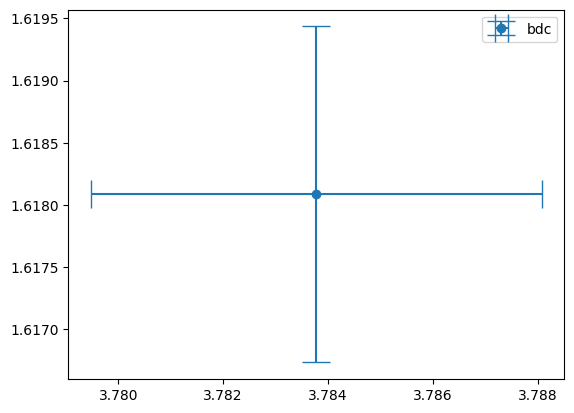

In [12]:
ax = kepler47.plot_triplet(error=True, capsize=10)
ax.legend()

If we want to plot some 3-body mean motion resonaces near the system triplets, we can invoke the `resokit.utils.mmr.plot_mmrs`_` method. 

This method will plot the resonances that are near the triplets.

Note: It its higly recommended to set the axes limits (xlim and ylim) **before** calling `plot_mmrs`, especially if *label_mmrs=True*.

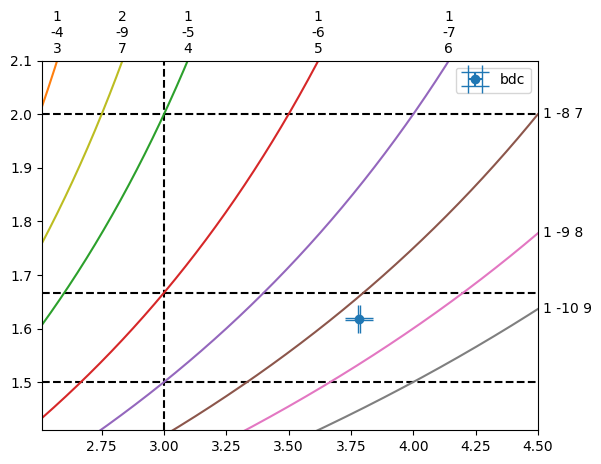

In [13]:
bounds = [2.51, 4.5, 1.41, 2.1]  # [xmin, xmax, ymin, ymax]
ax = kepler47.plot_triplet(error=True, capsize=10, label=True)
ax.set_xlim(bounds[0], bounds[1])
ax.set_ylim(bounds[2], bounds[3])
resokit.utils.mmr.plot_mmrs(
    bounds=bounds,
    ax=ax,
    label_mmrs=True
    )
ax.legend()

Here, the 3-body resonances are annotated with the corresponding period ratios.

### Plot

We can plot any pair atributes of the StaticSystem, of any planet in the system.

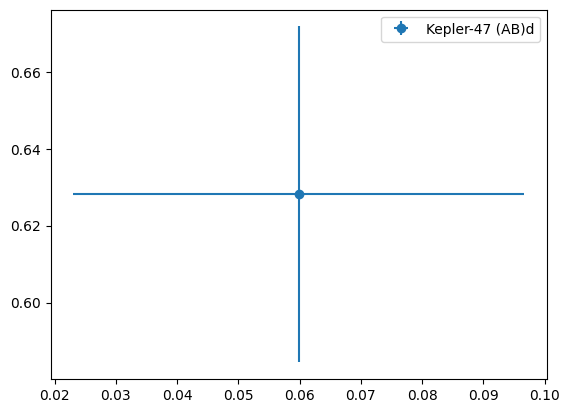

In [14]:
ax = kepler47.plot("mass", "radius", error_x=True, error_y=True)
ax.legend()

Some planets are not plotted because they do not have both requested attributes measured.

For example, in this case...

In [15]:
kepler47["radius"]

Kepler-47 (AB)b    0.2700
Kepler-47 (AB)d    0.6281
Kepler-47 (AB)c    0.4100
Name: radius, dtype: float64

We see the three planets have radius estimations; but...

In [16]:
kepler47["mass"]

Kepler-47 (AB)b        NaN
Kepler-47 (AB)d    0.05984
Kepler-47 (AB)c        NaN
Name: mass, dtype: float64

only `Kepler-47 (AB)d` has its mass estimated.

**EXTRA**

`ResoKit` also provides tools for mass (or radius) estimation with diverse models, from the estimated radius (or mass).

To do so, we simply use `estimate_mass` function.

In [17]:
kepler47.estimate_mass()

Kepler-47 (AB)b    0.000528
Kepler-47 (AB)d    0.010891
Kepler-47 (AB)c    0.002361
Name: mass, dtype: float64

Here we used the default `estimate_mass` parameters, but we can get different estimations with different models, including also the errors.

In [18]:
kepler47.estimate_mass(model="m24", err_method=2)

,mass,mass_err_min,mass_err_max
Kepler-47 (AB)b,0.000324,-0.000046,0.000052
Kepler-47 (AB)d,0.007399,-0.001734,0.002093
Kepler-47 (AB)c,0.001524,-0.000234,0.000263


## Remove or add planets

### Remove

To remove a planet, we can simply invoke the `remove_planet` method of StaticSystem.

In [19]:
modified_kepler47 = kepler47.remove_planet(2)  # Remember python is 0 indexed, so the third planet is "2".
modified_kepler47

Planet Kepler-47 (AB)c [2] removed.


StaticSystem: 
 Star:
  Kepler-47 A 
 Planets:
  Kepler-47 (AB)b
  Kepler-47 (AB)d
 from 'eu' data source.

We can also remove planets by name.

In [20]:
modified_kepler47 = kepler47.remove_planet("b")
modified_kepler47

Planet Kepler-47 (AB)b [0] removed.


StaticSystem: 
 Star:
  Kepler-47 A 
 Planets:
  Kepler-47 (AB)d
  Kepler-47 (AB)c
 from 'eu' data source.

In [21]:
# We check that the number of planets has been reduced
modified_kepler47.n_planets_

2

We can look the new system metadata, and we will find that 'removed_planet' has been added. Also some extra information can be found...

In [22]:
for k,v in modified_kepler47.metadata.items():
    print(k, v)

ResoKit 0.0.1
author Emmanuel Gianuzzi
author_email egianuzzi@unc.edu.ar
affiliation FAMAF-IATE-OAC-CONICET
platform Linux-6.8.0-49-generic-x86_64-with-glibc2.35
system_encoding utf-8
python 3.10.12 (main, Nov  6 2024, 20:22:13) [GCC 11.4.0]
license MIT
load_system Kepler-47 A
eu_index 4674
removed_planet Kepler-47 (AB)b


### Add

To add a planet, we can simply invoke the `add_planet` method of StaticSystem.

In [23]:
# Get a planet from the original system
planet2 = kepler47.planet(1)  # Remember python is 0 indexed, so the second planet is "1".

In [24]:
# Add the planet to the modified system
modified_kepler47.add_planet(planet2)

Planet Kepler-47 (AB)d added.


<attrs generated init resokit.core.StaticSystem>:20: UserWarning: Planets must have unique names.
  self.__attrs_post_init__()


StaticSystem: 
 Star:
  Kepler-47 A 
 Planets:
  Kepler-47 (AB)d
  Kepler-47 (AB)d
  Kepler-47 (AB)c
 from 'eu' data source.

Here, we added a planet that already exists in the system, so a Warning was raised.

In [25]:
# Extract the planet 2 from the original system
planet2 = kepler47.planet(1)  # Remember python is 0 indexed, so the second planet is "1".

# Remove the planet from the original system
modified_kepler47 = kepler47.remove_planet(1)

# Add the planet to the modified system
modified_kepler47 = modified_kepler47.add_planet(planet2)

# Check that the planet has been added
modified_kepler47

Planet Kepler-47 (AB)d [1] removed.
Planet Kepler-47 (AB)d added.


StaticSystem: 
 Star:
  Kepler-47 A 
 Planets:
  Kepler-47 (AB)b
  Kepler-47 (AB)d
  Kepler-47 (AB)c
 from 'eu' data source.